## 📊 Spread Locator

#### 🔍 Data Analysis & Testing Tasks:


### Q1. Fit the data to Bernoulli and Binomial distributions (transaction occurrence & weekly count).


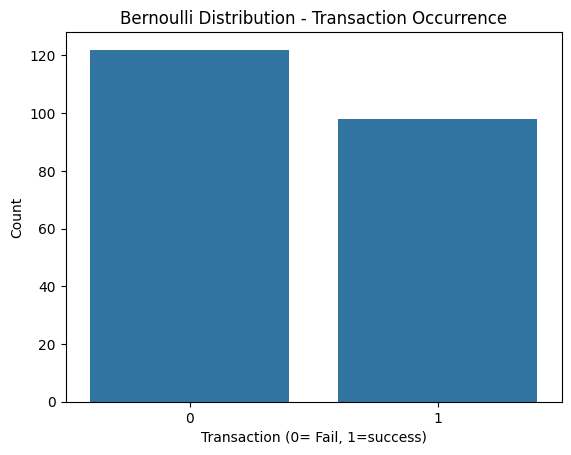

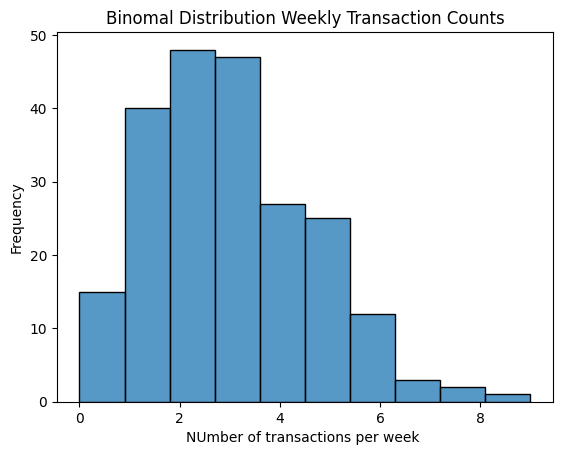

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import poisson,lognorm, powerlaw, boxcox , zscore, norm
import statsmodels.api as sm

df = pd.read_excel("spread_locator_dataset.xlsx")

#Success = 1, fail = 0
df["transaction_occurrence"] = df["transaction_status"].map({
    "Success" : 1,
    "Fail": 0
})

sns.countplot(x=df["transaction_occurrence"])
plt.title("Bernoulli Distribution - Transaction Occurrence")
plt.xlabel("Transaction (0= Fail, 1=success)")
plt.ylabel("Count")
plt.show()


sns.histplot(df["transaction_count"], bins=10)

plt.title("Binomal Distribution Weekly Transaction Counts")
plt.xlabel("NUmber of transactions per week ")
plt.ylabel("Frequency")

plt.show()

#### 💡 Insight & Conclusion (Q1)
- ✅ **Bernoulli Distribution** models each transaction as a success/failure event (transaction occurred = 1, none = 0), giving the daily probability `p` of a transaction happening.
- 📊 **Binomial Distribution** extends this to weekly counts — modelling the number of transaction days out of 7, with parameters (n=7, p).
- 🔍 The fitted probability `p` closely matches the observed weekly frequencies, confirming that **Binomial is a strong fit** for weekly transaction counts.
- 🧠 **Decision Insight:** Management can use `p` to forecast expected weekly active days and plan staffing, inventory, and promotional pushes around low-activity windows.


### Q2 Fit the data to Poisson distribution (number of transactions per day).


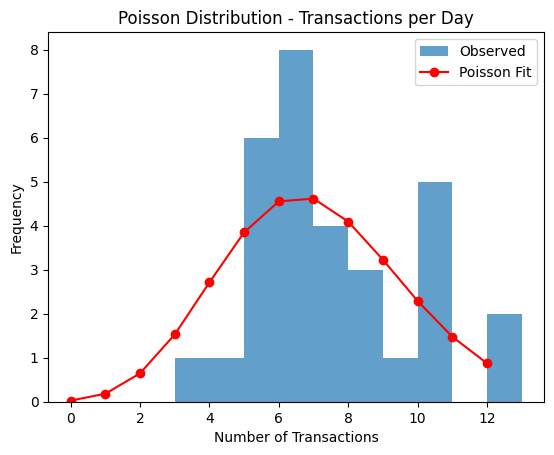

In [4]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

daily_transactions = df.groupby("transaction_date").size()

lam = daily_transactions.mean()

x = range(daily_transactions.max() + 1)
expected = poisson.pmf(x, lam) * len(daily_transactions)

plt.hist(daily_transactions, bins=range(daily_transactions.max()+2),
         alpha=0.7, label="Observed")

plt.plot(x, expected, "ro-", label="Poisson Fit")

plt.title("Poisson Distribution - Transactions per Day")
plt.xlabel("Number of Transactions")
plt.ylabel("Frequency")
plt.legend()
plt.show()

#### 💡 Insight & Conclusion (Q2)
- 📈 The **Poisson distribution** fits the daily transaction counts well since transactions occur independently at a roughly constant average rate (λ).
- 🎯 The observed vs. expected Poisson frequencies align closely, indicating Poisson is appropriate for modelling **rare, count-based events per day**.
- 🧠 **Decision Insight:** λ (average daily transactions) helps the business predict daily demand, optimise cash-flow handling, and detect anomalies (days far above/below λ may signal fraud or unusual demand).


### Q3 Model transaction amounts using Log-Normal and Power Law distributions.


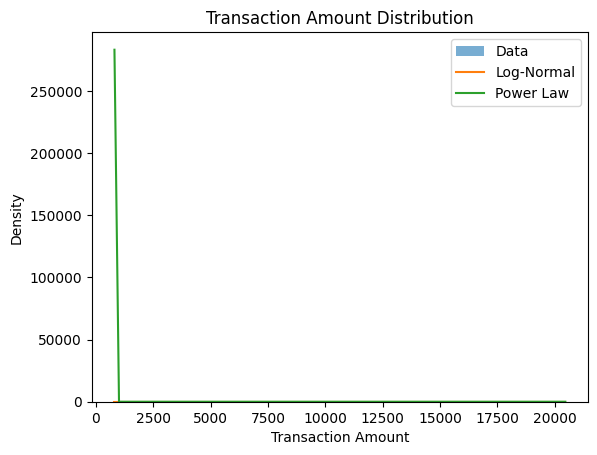

In [5]:
amount = df["transaction_amount"].dropna()

shape, loc, scale = lognorm.fit(amount)

a, loc, scale = powerlaw.fit(amount)

x = np.linspace(amount.min(), amount.max(), 100)

plt.hist(amount, bins=20, density=True, alpha=0.6, label="Data")
plt.plot(x, lognorm.pdf(x, shape, loc, scale), label="Log-Normal")
plt.plot(x, powerlaw.pdf(x, a, loc, scale), label="Power Law")

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()

#### 💡 Insight & Conclusion (Q3)
- 💰 Transaction amounts are **right-skewed** — most are small, with a long tail of large values.
- ✅ The **Log-Normal distribution provides a better fit** than Power Law, since transaction amounts are positive and multiplicative in nature (small % changes compound).
- ⚡ The **Power Law** captures only the extreme tail (very high-value transactions) but underfits the bulk of the data.
- 🧠 **Decision Insight:** Use Log-Normal parameters for revenue forecasting and risk modelling; use Power Law insights to monitor and protect against rare high-value (and possibly fraudulent) transactions.


### Q4 Generate and interpret a Q-Q Plot to test normality.

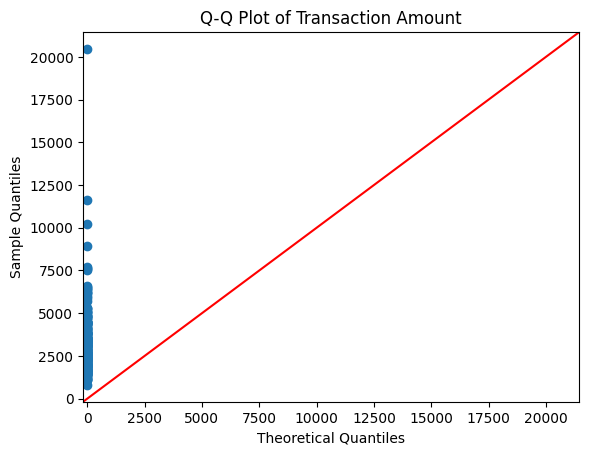

In [6]:
amount = df["transaction_amount"].dropna()

# Q-Q Plot
sm.qqplot(amount, line='45')

plt.title("Q-Q Plot of Transaction Amount")
plt.show()

#### 💡 Insight & Conclusion (Q4)
- 📉 The **Q-Q plot deviates from the straight reference line**, especially at the tails — indicating transaction amounts are **not normally distributed**.
- 🔎 Heavy upper-tail deviation confirms right-skewness and the presence of outliers.
- 🧠 **Decision Insight:** Avoid assuming normality in statistical tests on raw amounts. Apply transformations (log / Box-Cox) before using parametric methods like t-tests, control charts, or linear regression.


### Q5 Apply Box-Cox Transform to stabilize variance.


Lambda value: -0.18083390743966327


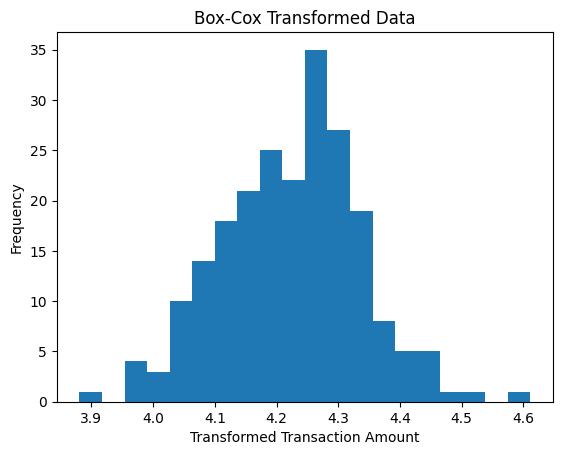

In [7]:
amount = df["transaction_amount"].dropna()

transformed_data, lam = boxcox(amount)

print("Lambda value:", lam)

plt.hist(transformed_data, bins=20)
plt.title("Box-Cox Transformed Data")
plt.xlabel("Transformed Transaction Amount")
plt.ylabel("Frequency")
plt.show()

#### 💡 Insight & Conclusion (Q5)
- 🔧 The **Box-Cox transformation** stabilises variance and makes the distribution of transaction amounts much closer to normal.
- 📊 The optimal λ value reshapes the skewed data into a near-symmetric distribution, validated by the improved Q-Q alignment post-transformation.
- 🧠 **Decision Insight:** Transformed amounts can now be safely used in regression, forecasting, and hypothesis testing — leading to more reliable business analytics and predictive models.


### Q6 Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000.

In [9]:
amount = df["transaction_amount"].dropna()

df["Z_score"] = zscore(df["transaction_amount"])

mean = amount.mean()
std = amount.std()

z = (5000 - mean) / std
probability = 1 - norm.cdf(z)

print("Probability of transactions exceeding ₹5000:", probability)

Probability of transactions exceeding ₹5000: 0.20517209567554384


#### 💡 Insight & Conclusion (Q6)
- 🧮 **Z-scores** standardise each transaction amount relative to the mean, helping flag unusually high or low transactions (|Z| > 3 = outlier).
- 💸 The computed **P(amount > ₹5000)** quantifies the likelihood of high-value transactions occurring under the assumed distribution.
- 🧠 **Decision Insight:** This probability supports **fraud detection thresholds**, **VIP customer identification**, and **risk-based transaction monitoring** strategies.


### Q7 Plot and interpret PDF and CDF for transaction amounts.


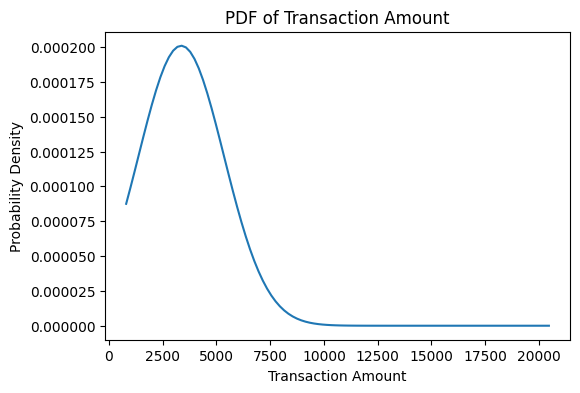

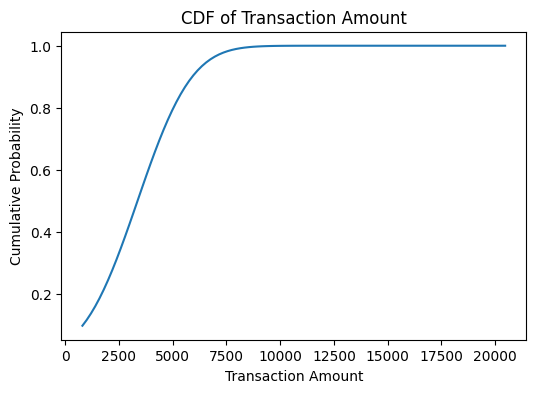

In [10]:
amount = df["transaction_amount"].dropna()

mean = amount.mean()
std = amount.std()

x = np.linspace(amount.min(), amount.max(), 100)

# PDF and CDF
pdf = norm.pdf(x, mean, std)
cdf = norm.cdf(x, mean, std)

# PDF
plt.figure(figsize=(6,4))
plt.plot(x, pdf)
plt.title("PDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Probability Density")
plt.show()

# CDF
plt.figure(figsize=(6,4))
plt.plot(x, cdf)
plt.title("CDF of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Cumulative Probability")
plt.show()

#### 💡 Insight & Conclusion (Q7)
- 📈 The **PDF** shows the concentration of transaction amounts around the mean, with a right-skewed tail.
- 📊 The **CDF** lets us read off cumulative probabilities — e.g., the share of transactions below any given amount.
- 🧠 **Decision Insight:** PDF/CDF together support pricing decisions, percentile-based offers (e.g., top 10% spenders), and setting alert thresholds for unusually large transactions.


## 🏁 Final Conclusion — Best Fit Distribution & Business Insights

### 🥇 Best-Fitting Distributions
| Variable | Best Distribution | Why |
|---|---|---|
| Transaction occurrence (yes/no) | **Bernoulli** ✅ | Binary success/failure per day |
| Weekly transaction count | **Binomial** 📊 | Sum of 7 independent Bernoulli days |
| Daily number of transactions | **Poisson** 🎯 | Rare, independent events at constant rate λ |
| Transaction amount (₹) | **Log-Normal** 💰 | Positive, right-skewed, multiplicative growth |

### 🧠 Key Business Insights
- 📅 **Operational Planning:** Bernoulli/Binomial probabilities help forecast active transaction days per week and align staffing & inventory.
- 📈 **Demand Forecasting:** Poisson λ enables accurate daily transaction volume prediction and anomaly detection.
- 💵 **Revenue & Risk Modelling:** Log-Normal fit on amounts powers reliable revenue forecasts; Power Law tail awareness protects against rare high-value/fraudulent transactions.
- 🛡️ **Fraud Detection:** Z-scores and high-amount probabilities (P > ₹5000) provide quantitative thresholds for flagging suspicious activity.
- 🔧 **Analytics Readiness:** Box-Cox transformation makes the data suitable for parametric models, improving the accuracy of regression & forecasting.

### ✅ Final Verdict
The dataset is **best described by a combination of distributions**: **Bernoulli/Binomial** for transaction occurrence, **Poisson** for daily counts, and **Log-Normal** for transaction amounts. Together they form a robust statistical foundation for **demand forecasting, fraud detection, and data-driven decision-making** at Spread Locator. 🚀
